In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Load dataset ──────────────────────────────────────────────────────
df = pd.read_csv('database.csv')

# ── Rename columns for consistency ────────────────────────────────────
df.columns = [
    'decl_number', 'decl_type', 'decl_date', 'state', 'county',
    'incident_type', 'disaster_title', 'start_date', 'end_date',
    'close_date', 'ind_assist', 'ih_program', 'pub_assist', 'haz_mitig'
]



In [17]:
# ── Frequency count ──────────────────────────────────────────────────
freq = df['incident_type'].value_counts().reset_index()
freq.columns = ['incident_type', 'count']

# ── Color palette ────────────────────────────────────────────────────
palette = sns.color_palette('Blues_r', len(freq))


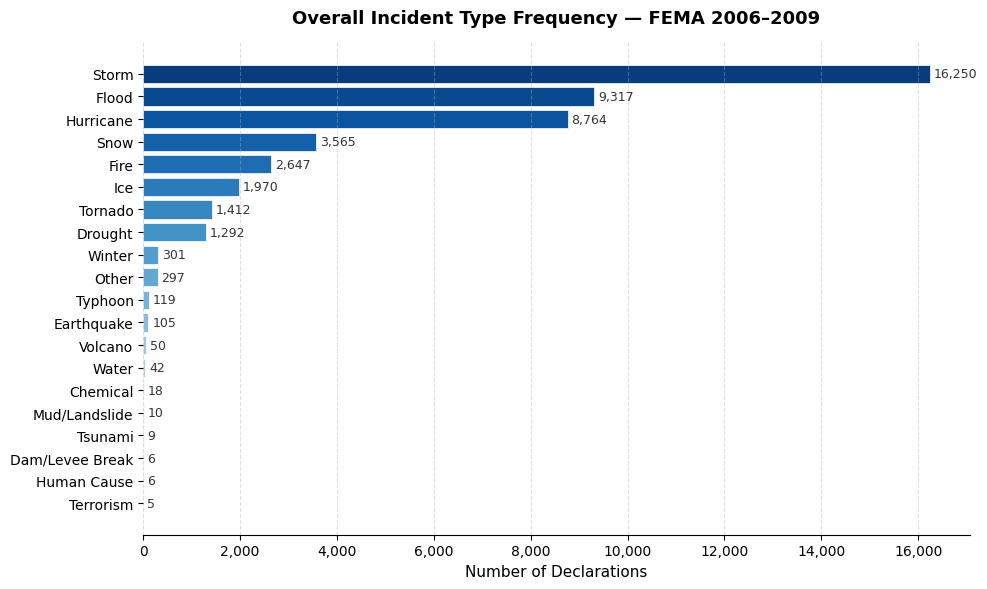

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(freq['incident_type'], freq['count'],
               color=palette, edgecolor='white', linewidth=0.5)

# ── Annotate bars ────────────────────────────────────────────────────
for bar, val in zip(bars, freq['count']):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#333333')

ax.set_xlabel('Number of Declarations', fontsize=11)
ax.set_title('Overall Incident Type Frequency — FEMA 2006–2009',
             fontsize=13, fontweight='bold', pad=14)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine(left=True)
plt.tight_layout()
plt.show()


In [33]:
# ── Treemap using Plotly ─────────────────────────────────────────────
fig = px.treemap(
    freq, path=['incident_type'], values='count',
    color='count',
    color_continuous_scale='reds',
    title='Incident Type Proportional Distribution (Treemap)'
)
fig.update_traces(textinfo='label+value+percent root',
                  textfont_size=13)
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()


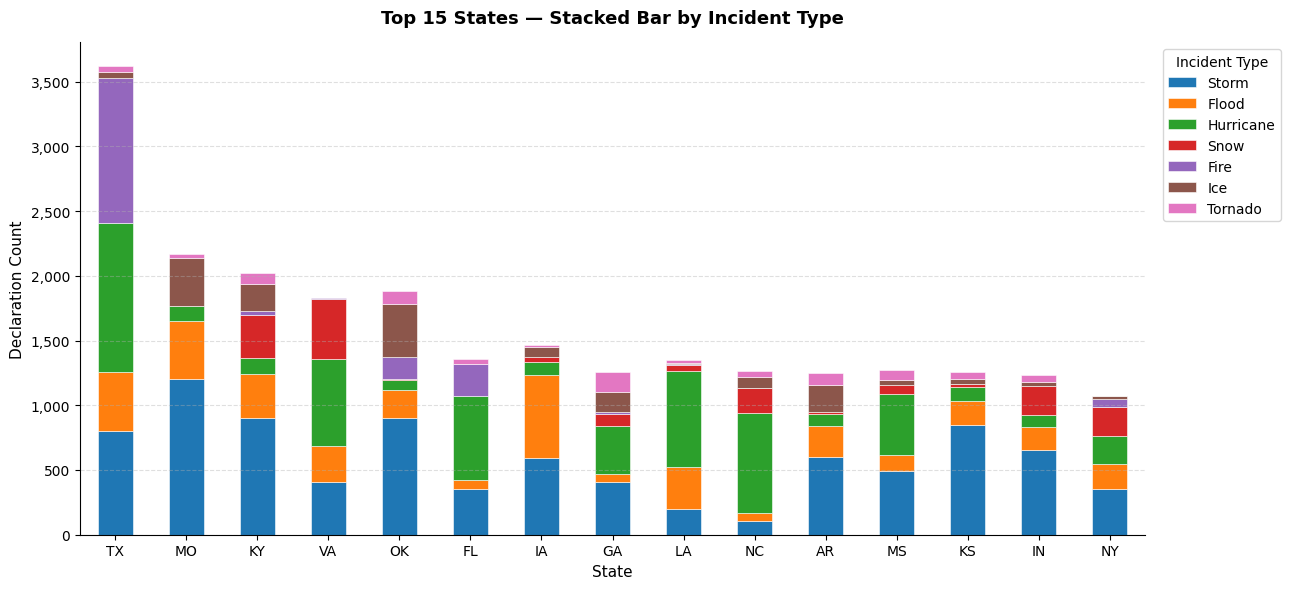

In [6]:
# ── Pivot: state × incident_type ────────────────────────────────────
top_states = df['state'].value_counts().head(15).index.tolist()
df_top = df[df['state'].isin(top_states)]

pivot = (df_top
         .groupby(['state', 'incident_type'])
         .size()
         .unstack(fill_value=0)
         .loc[top_states])

# Keep only top 7 incident types for readability
top_types = df['incident_type'].value_counts().head(7).index.tolist()
pivot = pivot[top_types]

# ── Plot ─────────────────────────────────────────────────────────────
colors = sns.color_palette('tab10', len(top_types))
ax = pivot.plot(kind='bar', stacked=True, figsize=(13, 6),
                color=colors, edgecolor='white', linewidth=0.4)

ax.set_xlabel('State', fontsize=11)
ax.set_ylabel('Declaration Count', fontsize=11)
ax.set_title('Top 15 States — Stacked Bar by Incident Type',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Incident Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.savefig('fig3_stacked_bar_states.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# ── Full state × type heatmap (top 20 states) ───────────────────────
top20 = df['state'].value_counts().head(20).index.tolist()
heat_data = (df[df['state'].isin(top20)]
             .groupby(['state', 'incident_type'])
             .size()
             .unstack(fill_value=0))

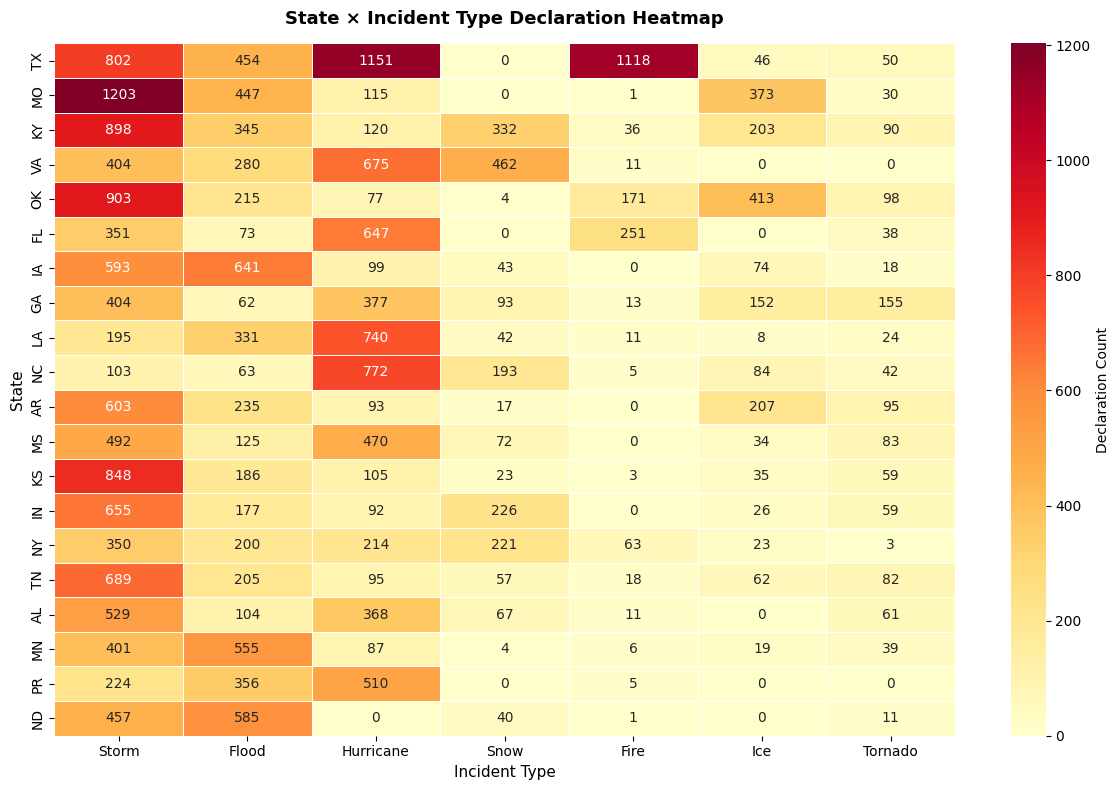

In [21]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heat_data[top_types].loc[top20],
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Declaration Count'},
    ax=ax
)
ax.set_title('State × Incident Type Declaration Heatmap',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Incident Type', fontsize=11)
ax.set_ylabel('State', fontsize=11)
plt.tight_layout()
plt.savefig('fig4_heatmap_state_type.png', dpi=150, bbox_inches='tight')
plt.show()


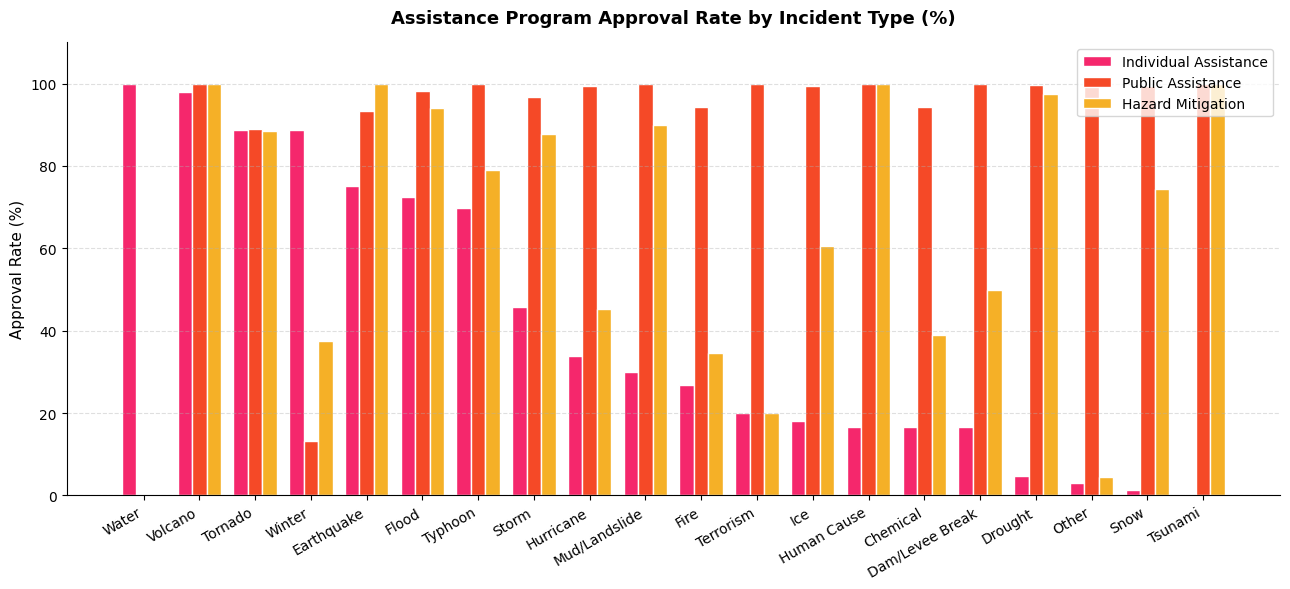

In [36]:
for col in ['ind_assist', 'ih_program', 'pub_assist', 'haz_mitig']:
    df[col + '_bin'] = (df[col].str.strip().str.lower() == 'yes').astype(int)

# ── Approval rates per incident type ────────────────────────────────
prog_cols = ['ind_assist_bin', 'pub_assist_bin', 'haz_mitig_bin']
prog_labels = ['Individual Assistance', 'Public Assistance', 'Hazard Mitigation']

rate = (df.groupby('incident_type')[prog_cols]
          .mean()
          .multiply(100)
          .round(1)
          .reset_index())
rate.columns = ['incident_type'] + prog_labels

# Sort by Individual Assistance rate
rate = rate.sort_values('Individual Assistance', ascending=False)

x = np.arange(len(rate))
width = 0.26
fig, ax = plt.subplots(figsize=(13, 6))

for i, (col, color) in enumerate(zip(prog_labels,
                                ['#F5276C','#F54927','#F5B027'])):
    ax.bar(x + i*width, rate[col], width,
           label=col, color=color, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(rate['incident_type'], rotation=30, ha='right')
ax.set_ylabel('Approval Rate (%)', fontsize=11)
ax.set_title('Assistance Program Approval Rate by Incident Type (%)',
             fontsize=13, fontweight='bold', pad=14)
ax.legend()
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()


In [25]:
# ── Create program combination label ────────────────────────────────
df['prog_combo'] = (
    df['ind_assist'].str.strip() + ' IA / ' +
    df['pub_assist'].str.strip() + ' PA'
)


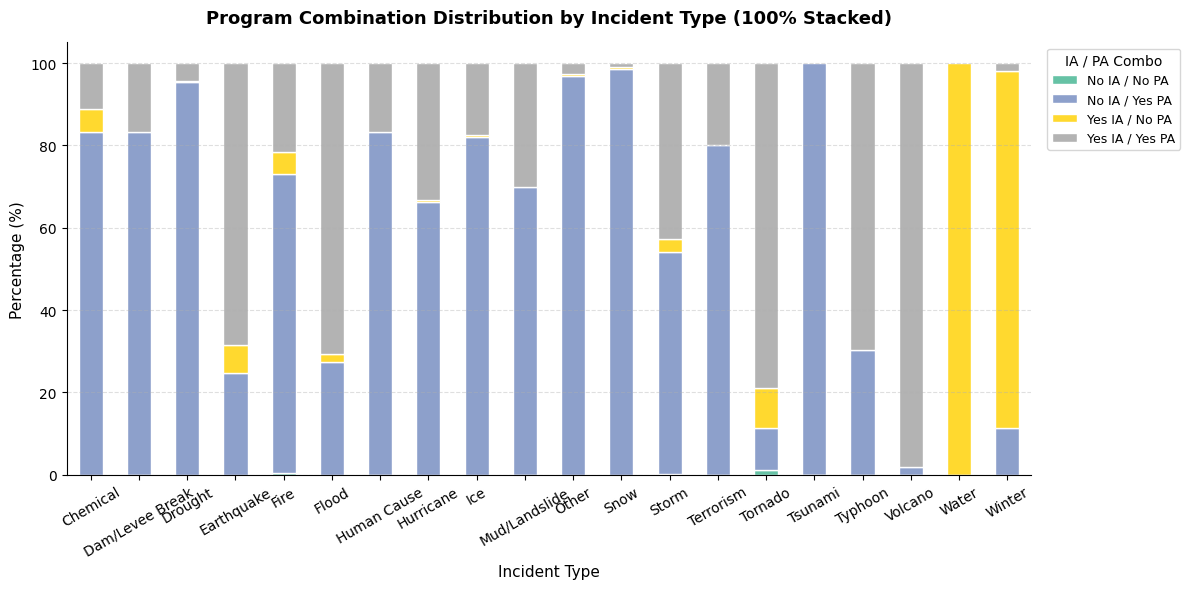

In [37]:
combo_pivot = (df.groupby(['incident_type', 'prog_combo'])
                 .size()
                 .unstack(fill_value=0))

# Normalize to 100%
combo_pct = combo_pivot.div(combo_pivot.sum(axis=1), axis=0) * 100

ax = combo_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                    colormap='Set2', edgecolor='white')
ax.set_xlabel('Incident Type', fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=11)
ax.set_title('Program Combination Distribution by Incident Type (100% Stacked)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=30)
ax.legend(title='IA / PA Combo', bbox_to_anchor=(1.01,1), loc='upper left',
          fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()


In [39]:
df['decl_date'] = pd.to_datetime(df['decl_date'])
df['year'] = df['decl_date'].dt.year

# ── Annual declarations by top incident types ────────────────────────
annual = (
    df.groupby(['year', 'incident_type'])
    .size()
    .reset_index(name='count')
)
top5 = df['incident_type'].value_counts().head(5).index.tolist()
annual_top = annual[annual['incident_type'].isin(top5)]

fig = px.line(
    annual_top, x='year', y='count',
    color='incident_type',
    markers=True,
    title='Annual Declarations by Top 5 Incident Types',
    labels={'count': 'Declarations', 'year': 'Year',
            'incident_type': 'Type'}
)
fig.update_layout(legend=dict(orientation='h', y=-0.2))
fig.show()



In [40]:
# ── State + incident type dual view ──────────────────────────────────
state_type = (
    df.groupby(['state', 'incident_type'])
    .size()
    .reset_index(name='count')
)
state_type_top = state_type[
    state_type['state'].isin(top_states) &
    state_type['incident_type'].isin(top5)
]

fig2 = px.scatter(
    state_type_top,
    x='state', y='incident_type', size='count',
    color='incident_type',
    title='Bubble Chart: State × Incident Type Declaration Volume',
    labels={'count': 'Declarations'}
)
fig2.show()